In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)



In [2]:
data25 = pd.read_csv('data/2025.csv')
data24 = pd.read_csv('data/2024.csv')
data23 = pd.read_csv('data/2023.csv')
data22 = pd.read_csv('data/2022.csv')
data21 = pd.read_csv('data/2021.csv')
data20 = pd.read_csv('data/2020.csv')
data19 = pd.read_csv('data/2019.csv')
data18 = pd.read_csv('data/2018.csv')
data17 = pd.read_csv('data/2017.csv')
data16 = pd.read_csv('data/2016.csv')

In [3]:
outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup', 'strikeout', 'strikeout_double_play'
]

strikeout_code = ['strikeout', 'strikeout_double_play']

swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

bip_code = ['hit_into_play']

hit_code = ['single', 'double', 'triple', 'home_run']

walk_code = ['walk', 'intent_walk', 'hit_by_pitch']

strike_code = ['swinging_strike', 'swinging_strike_blocked', 'called_strike',  'missed_bunt']

foul_code = ['foul', 'foul_bunt', 'foul_tip', 'bunt_foul_tip']

ball_code = ['ball', 'blocked_ball']


In [4]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from model_shared.db import get_read_cursor

def categorize_pitch(row):
    event = row['events']
    bb_type = row['bb_type']
    description = row['description']

    if event in strikeout_code:
        return 'strikeout'
    elif event in out_code:
        if bb_type == 'ground_ball':
            return 'groundout'
        elif bb_type in ['fly_ball', 'line_drive', 'popup']:
            return 'flyout'
    elif event in hit_code:
        return 'hit'
    elif event in walk_code:
        return 'walk'
    
    if description in strike_code:
        return 'strike'
    elif description in foul_code:
        return 'foul'
    elif description in ball_code:
        return 'ball'
    
    return 'other'
        

def get_historical_data(year=2024):
    query = """
        SELECT
            bb.player_id,
            bb.position,
            bb.ground_ball_percentage,
            bb.air_ball_percentage,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            qoc.weak_percentage,
            qoc.under_percentage,
            qoc.topped_percentage,
            qoc.flareburner_percentage,
            qoc.solid_percentage,
            qoc.barrel_percentage,
            qoc.barrels_per_pa,
            pt.pitch_type,
            pt.pitch_count,
            pt.strikeouts,
            pt.batted_ball_events,
            pt.batting_average,
            pt.putaway_percentage,
            pt.whiff_percentage AS pitch_whiff_percentage,
            pt.launch_angle AS average_launch_angle,
            pt.exit_velocity AS average_exit_velocity,
            pt.expected_batting_average,
            pt.mph AS average_mph
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN quality_of_contact qoc
            ON bb.player_id = qoc.player_id
            AND bb.position = qoc.position
            AND bb.year = qoc.year
        JOIN pitch_tracking pt
            ON bb.player_id = pt.player_id
            AND bb.position = pt.position
            AND bb.year = pt.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df

def df_process(df):
    df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

    df['outcome'] = df.apply(categorize_pitch, axis=1)

    df['prev_pitch_type'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
    df['prev_pitch_type'] = df['prev_pitch_type'].fillna('NONE')

    df['runner_on_1b'] = df['on_1b'].notna().astype(int)
    df['runner_on_2b'] = df['on_2b'].notna().astype(int)
    df['runner_on_3b'] = df['on_3b'].notna().astype(int)

    return df

In [5]:
def get_features(out_data, features):
    final_features = list(features)

    model_data = out_data[final_features]

    cat_cols = ['prev_pitch_type', 'pitch_type', 'stand', 'p_throws', 'inning_topbot']

    existing_cat_cols = [c for c in cat_cols if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=existing_cat_cols, drop_first=True)
    return model_data

def get_zone_metrics(year=2024):
    query = """
        SELECT
            player_id,
            position,
            metric,
            zone1,
            zone2,
            zone3,
            zone4,
            zone5,
            zone6,
            zone7,
            zone8,
            zone9,
            zone11,
            zone12,
            zone13,
            zone14
        FROM zone_metrics
        WHERE year = %s
            AND metric IN ('batting_average', 'average_exit_velocity', 
                          'average_launch_angle', 'contact_batting_average',
                          'hard_hit_bip_percentage', 'expected_batting_average',
                          'strikeout_percentage', 'whiff_percentage', 'walk_percentage', 'ground_ball_percentage',
                          'line_drive_percentage', 'fly_ball_percentage', 'popup_percentage', 'swing_percentage'
                          )
    """
    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))

    df_long = pd.melt(
        df, 
        id_vars=['player_id', 'position', 'metric'], 
        var_name='zone', 
        value_name='metric_value'
    )
    df_long['zone'] = df_long['zone'].str.replace('zone', '').astype(int)
    
    df_final = df_long.pivot_table(
        index=['player_id', 'position', 'zone'], 
        columns='metric', 
        values='metric_value'
    ).reset_index()
    
    return df_final


features = [
    'release_speed',
    'plate_x',
    'plate_z',
    'pfx_x',
    'pfx_z',
    'release_pos_x',
    'release_pos_z',
    'release_extension',
    'spin_axis',
    'release_spin_rate',
    'p_throws', 
    'stand', 
    'balls', 
    'pitch_type',
    'zone',
    'strikes', 
    'runner_on_1b',
    'runner_on_2b', 
    'runner_on_3b', 
    'outs_when_up', 
    'inning',
    'bat_score',
    'fld_score',
    'inning_topbot',
    'sz_top',
    'sz_bot',
    'bb_type',
    'prev_pitch_type',
    # 'batter_rolling_whiff_rate', 
    # 'batter_rolling_gb_rate', 
    # 'batter_rolling_fb_rate', 
    'batter_prev_whiff_rate', 
    'batter_prev_gb_rate', 
    'batter_prev_fb_rate',
    'batter_prev_chase_rate',
    'batter_prev_weak_rate',
    'batter_prev_under_rate',
    'batter_prev_topped_rate',
    'batter_prev_flareburner_rate',
    'batter_prev_solid_rate',
    'batter_prev_barrel_rate',
    'batter_prev_barrels_per_pa',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    'pitcher_prev_fb_rate', 
    'pitcher_prev_gb_rate', 
    'pitcher_prev_whiff_rate', 
    'game_year',
    'game_date', 'game_pk', 'pitch_number',
    # 'pitcher_rolling_whiff_rate', 
    # 'pitcher_rolling_gb_rate', 
    # 'pitcher_rolling_fb_rate', 
    'pitcher_prev_chase_rate',
    'pitcher_prev_weak_rate',
    'pitcher_prev_under_rate',
    'pitcher_prev_topped_rate',
    'pitcher_prev_flareburner_rate',
    'pitcher_prev_solid_rate',
    'pitcher_prev_barrel_rate',
    'pitcher_prev_barrels_per_pa',
    'outcome',
    'pitcher_pitch_putaway_rate',
    'batter_pitch_putaway_rate',
    'pitcher_pitch_whiff_rate',
    'batter_pitch_whiff_rate',
    'pitcher_pitch_average_launch_angle',
    'pitcher_pitch_average_exit_velocity',
    'pitcher_pitch_expected_batting_average',
    'batter_pitch_average_launch_angle',
    'batter_pitch_average_exit_velocity',
    'batter_pitch_expected_batting_average',
    'pitcher_pitch_batting_average',
    'batter_pitch_batting_average',
    'pitcher_zone_batting_average',
    'batter_zone_batting_average',
    'pitcher_zone_average_exit_velocity',
    'batter_zone_average_exit_velocity',
    'pitcher_zone_average_launch_angle',
    'batter_zone_average_launch_angle',
    'pitcher_zone_contact_batting_average',
    'batter_zone_contact_batting_average',
    'pitcher_zone_hard_hit_bip_percentage',
    'batter_zone_hard_hit_bip_percentage',
    'pitcher_zone_expected_batting_average',
    'batter_zone_expected_batting_average',
    'batter_zone_strikeout_percentage',
    'pitcher_zone_strikeout_percentage',
    'batter_zone_whiff_percentage',
    'pitcher_zone_whiff_percentage',
    'batter_zone_fly_ball_rate',
    'pitcher_zone_fly_ball_rate',
    'batter_zone_walk_percentage',
    'pitcher_zone_walk_percentage',
    'batter_zone_ground_ball_percentage',
    'pitcher_zone_ground_ball_percentage',
    'batter_zone_swing_percentage',
    'pitcher_zone_swing_percentage',
    'pitcher_pitch_average_mph',
    'batter_pitch_average_mph'
]


def build_season_features(current_pitch_data, historical_year):
    historical_df = get_historical_data(historical_year)
    zone_metrics_df = get_zone_metrics(historical_year)

    prev_cols = [
        'player_id', 'position', 'ground_ball_percentage', 'air_ball_percentage',
        'whiff_percentage', 'chase_percentage', 'weak_percentage', 
        'under_percentage', 'topped_percentage', 'zone_contact_percentage',
        'zone_percentage', 'zone_swing_percentage', 'flareburner_percentage', 'solid_percentage', 'barrel_percentage', 'barrels_per_pa'
    ]

    batter_baselines = historical_df[historical_df['position'] == 'B'][prev_cols].drop_duplicates().add_prefix('batter_prev_')
    pitcher_baselines = historical_df[historical_df['position'] == 'P'][prev_cols].drop_duplicates().add_prefix('pitcher_prev_')

    pitch_data = current_pitch_data.merge(batter_baselines, left_on='batter', right_on='batter_prev_player_id', how='left')
    pitch_data = pitch_data.merge(pitcher_baselines, left_on='pitcher', right_on='pitcher_prev_player_id', how='left')

    pt_cols = [
        'player_id', 'position', 'pitch_type', 'pitch_count', 'strikeouts', 'batted_ball_events',
        'batting_average', 'putaway_percentage', 'pitch_whiff_percentage', 'average_launch_angle', 'average_exit_velocity', 'expected_batting_average',
        'average_mph'
    ]

    batter_pt = historical_df[historical_df['position'] == 'B'][pt_cols].drop_duplicates().add_prefix('batter_pitch_')
    pitcher_pt = historical_df[historical_df['position'] == 'P'][pt_cols].drop_duplicates().add_prefix('pitcher_pitch_')

    pitch_data = pitch_data.merge(batter_pt, left_on=['batter', 'pitch_type'], right_on=['batter_pitch_player_id', 'batter_pitch_pitch_type'], how='left')
    pitch_data = pitch_data.merge(pitcher_pt, left_on=['pitcher', 'pitch_type'], right_on=['pitcher_pitch_player_id', 'pitcher_pitch_pitch_type'], how='left')

    batter_zone = zone_metrics_df[zone_metrics_df['position'] == 'B'].add_prefix('batter_zone_')
    pitcher_zone = zone_metrics_df[zone_metrics_df['position'] == 'P'].add_prefix('pitcher_zone_')

    pitch_data = pitch_data.merge(batter_zone, left_on=['batter', 'zone'], right_on=['batter_zone_player_id', 'batter_zone_zone'], how='left')
    pitch_data = pitch_data.merge(pitcher_zone, left_on=['pitcher', 'zone'], right_on=['pitcher_zone_player_id', 'pitcher_zone_zone'], how='left')

    pitch_data = pitch_data.rename(columns={
        'batter_prev_ground_ball_percentage': 'batter_prev_gb_rate', 
        'batter_prev_air_ball_percentage': 'batter_prev_fb_rate',
        'batter_prev_whiff_percentage': 'batter_prev_whiff_rate',
        'batter_prev_chase_percentage': 'batter_prev_chase_rate',
        'batter_prev_weak_percentage': 'batter_prev_weak_rate',
        'batter_prev_under_percentage': 'batter_prev_under_rate',
        'batter_prev_topped_percentage': 'batter_prev_topped_rate',
        'batter_prev_flareburner_percentage': 'batter_prev_flareburner_rate',
        'batter_prev_solid_percentage': 'batter_prev_solid_rate',
        'batter_prev_barrel_percentage': 'batter_prev_barrel_rate',
        'batter_prev_barrels_per_pa': 'batter_prev_barrels_per_pa',
        'batter_prev_zone_contact_percentage': 'batter_prev_zone_contact_rate',
        'batter_pitch_putaway_percentage': 'batter_pitch_putaway_rate',
        'batter_pitch_pitch_whiff_percentage': 'batter_pitch_whiff_rate',
        'pitcher_prev_ground_ball_percentage': 'pitcher_prev_gb_rate', 
        'pitcher_prev_air_ball_percentage': 'pitcher_prev_fb_rate',
        'pitcher_prev_whiff_percentage': 'pitcher_prev_whiff_rate',
        'pitcher_prev_chase_percentage': 'pitcher_prev_chase_rate',
        'pitcher_prev_weak_percentage': 'pitcher_prev_weak_rate',
        'pitcher_prev_under_percentage': 'pitcher_prev_under_rate',
        'pitcher_prev_topped_percentage': 'pitcher_prev_topped_rate',
        'pitcher_prev_flareburner_percentage': 'pitcher_prev_flareburner_rate',
        'pitcher_prev_solid_percentage': 'pitcher_prev_solid_rate',
        'pitcher_prev_barrel_percentage': 'pitcher_prev_barrel_rate',
        'pitcher_prev_barrels_per_pa': 'pitcher_prev_barrels_per_pa',
        'pitcher_pitch_putaway_percentage': 'pitcher_pitch_putaway_rate',
        'pitcher_pitch_pitch_whiff_percentage': 'pitcher_pitch_whiff_rate',
    })

    pitch_data['batter_prev_looking_strike_rate'] = pitch_data['batter_prev_zone_percentage'] * (1 - pitch_data['batter_prev_zone_swing_percentage'] / 100.0)
    pitch_data['batter_zone_fly_ball_rate'] = pitch_data['batter_zone_line_drive_percentage'] + pitch_data['batter_zone_fly_ball_percentage'] + pitch_data['batter_zone_popup_percentage']
    pitch_data['pitcher_zone_fly_ball_rate'] = pitch_data['pitcher_zone_line_drive_percentage'] + pitch_data['pitcher_zone_fly_ball_percentage'] + pitch_data['pitcher_zone_popup_percentage']

    pitch_data = pitch_data.drop(columns=[
        'batter_prev_zone_swing_percentage',
        'batter_prev_zone_percentage', 
        'pitcher_prev_zone_swing_percentage',
        'pitcher_prev_zone_percentage',
        'pitcher_prev_zone_contact_percentage',
    ])

    sql_pct_cols = [
        'batter_prev_fb_rate', 'batter_prev_gb_rate', 'batter_prev_whiff_rate',
        'batter_prev_chase_rate', 'batter_prev_weak_rate', 'batter_prev_under_rate',
        'batter_prev_topped_rate', 'batter_prev_flareburner_rate', 'batter_prev_solid_rate', 'batter_prev_barrel_rate', 
        'batter_prev_barrels_per_pa', 'batter_prev_looking_strike_rate',
        'batter_prev_zone_contact_rate', 'batter_pitch_putaway_rate',
        'batter_pitch_whiff_rate', 'pitcher_prev_fb_rate', 'pitcher_prev_gb_rate',
        'pitcher_prev_whiff_rate', 'pitcher_prev_chase_rate', 'pitcher_prev_weak_rate',
        'pitcher_prev_under_rate', 'pitcher_prev_topped_rate', 'pitcher_prev_flareburner_rate', 'pitcher_prev_solid_rate', 'pitcher_prev_barrel_rate', 
        'pitcher_prev_barrels_per_pa', 'pitcher_pitch_putaway_rate', 'pitcher_pitch_whiff_rate'
    ]

    for col in sql_pct_cols:
        if col in pitch_data.columns:
            pitch_data[col] = pitch_data[col] / 100.0
            
    return pitch_data


df_25 = df_process(data25)
df_24 = df_process(data24)
df_23 = df_process(data23)
df_22 = df_process(data22)
df_21 = df_process(data21)
df_20 = df_process(data20)
df_19 = df_process(data19)
df_18 = df_process(data18)
df_17 = df_process(data17)
df_16 = df_process(data16)
pitch_data = []

for df, year in [
    (df_16, 2015),
    (df_17, 2016),
    (df_18, 2017),
    (df_19, 2018),
    (df_20, 2019),
    (df_21, 2020),
    (df_22, 2021),
    (df_23, 2022),
    (df_24, 2023),
    (df_25, 2024),
]:
    print(f"Building {year+1} features...")
    tmp = build_season_features(df, historical_year=year)
    pitch_data.append(tmp)

pitch_data = pd.concat(pitch_data, ignore_index=True)

print("Total combined rows:", len(pitch_data))

model_data = get_features(pitch_data, features)

Building 2016 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\4002506258.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\1060238617.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2017 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\4002506258.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\1060238617.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2018 features...


...

Building 2024 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\4002506258.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\1060238617.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2025 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\4002506258.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_2880\1060238617.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Total combined rows: 6829672


In [24]:
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.utils import compute_sample_weight
import xgboost as xgb
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss
import joblib

bip_labels = {
    'fly_ball': 0,
    'line_drive': 0,
    'popup': 0,
    'ground_ball': 1,
}

model_data['target1'] = model_data['outcome'].isin(['strikeout', 'groundout', 'flyout', 'hit']).astype(int)
model_data['target2'] = (model_data['outcome'] == 'strikeout').astype(int)
model_data['target3'] = model_data['bb_type'].map(bip_labels).fillna(-1).astype(int)

model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']

features = [col for col in model_data.columns if col not in ['target1', 'target2', 'target3', 'outcome', 'game_date', 'game_pk', 'pitch_number', 'bb_type']]
model_data = model_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

length = len(model_data)
train_end = int(length * 0.7)
val_end = int(length * 0.85)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

### Stage 1: Predict PA End vs Non-PA End, excluding walks

[0]	validation_0-logloss:0.66832
[100]	validation_0-logloss:0.51101
[200]	validation_0-logloss:0.50659
[300]	validation_0-logloss:0.50383
[400]	validation_0-logloss:0.50134
[500]	validation_0-logloss:0.49890
[600]	validation_0-logloss:0.49772
[700]	validation_0-logloss:0.49589
[800]	validation_0-logloss:0.49471
[900]	validation_0-logloss:0.49373
[989]	validation_0-logloss:0.49351
zone                                      0.270328
two_strikes                               0.108935
strikes                                   0.098389
prev_pitch_type_NONE                      0.045765
plate_x                                   0.028306
plate_z                                   0.026790
game_year                                 0.023346
batter_zone_swing_percentage              0.022015
pitch_type_CH                             0.017794
pitch_type_SI                             0.017513
pitch_type_FF                             0.015951
sz_bot                                    0.014910
balls

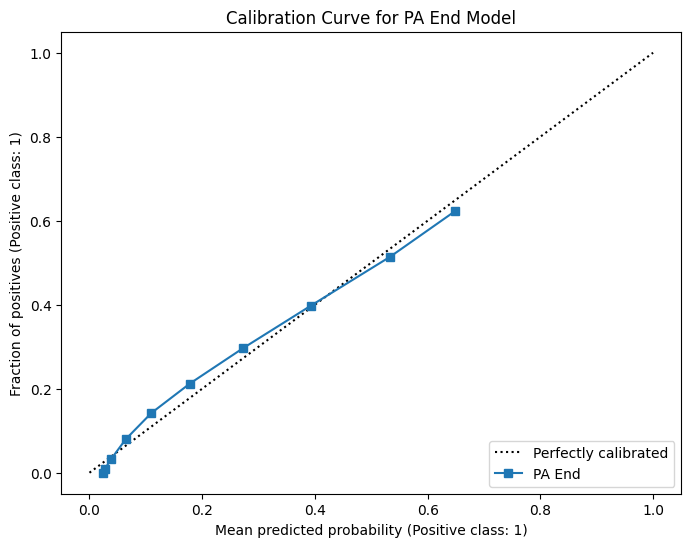

Probability metrics:
Log Loss: 0.40680
Brier Score: 0.13361
Distribution Check:
Real PA End Rate: 0.2308
Predicted Avg Prob: 0.2290
Simulated PA End Rate: 0.2291


In [ ]:
X1_train = train_data[features]
y1_train = train_data['target1']

X1_val = val_data[features]
y1_val = val_data['target1']

X1_test = test_data[features]
y1_test = test_data['target1']

weights = compute_sample_weight(class_weight='balanced', y=y1_train)


xgb_out = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_out.fit(X1_train, y1_train, eval_set=[(X1_val, y1_val)], verbose=100, sample_weight=weights)

calibrated_out = CalibratedClassifierCV(FrozenEstimator(xgb_out), method='sigmoid')
calibrated_out.fit(X1_val, y1_val)

y1_proba = calibrated_out.predict_proba(X1_test)[:, 1]

joblib.dump({
    'model': calibrated_out,
    'features': features
}, 'models/pa_end_model_v1.pkl')

importance = pd.Series(
    xgb_out.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y1_test == 1).astype(int),
    y1_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='PA End'
)
plt.title('Calibration Curve for PA End Model')
plt.show()

ll = log_loss(y1_test, y1_proba)
brier_score = brier_score_loss(y1_test, y1_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_pa_ends = (np.random.rand(len(y1_proba)) < y1_proba).astype(int)

real_rate = y1_test.mean()
pred_rate = y1_proba.mean()
sim_rate = simulated_pa_ends.mean()

print("Distribution Check:")
print(f"Real PA End Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated PA End Rate: {sim_rate:.4f}")

### Stage 2: Of PA Ends, predict Strikeout vs Non-Strikeout 

[0]	validation_0-logloss:0.52724
[100]	validation_0-logloss:0.30794
[200]	validation_0-logloss:0.30223
[300]	validation_0-logloss:0.29963
[400]	validation_0-logloss:0.29868
[500]	validation_0-logloss:0.29835
[516]	validation_0-logloss:0.29831
two_strikes                               0.491841
strikes                                   0.411052
prev_pitch_type_NONE                      0.025120
zone                                      0.009711
batter_zone_whiff_percentage              0.003927
plate_z                                   0.003537
batter_zone_strikeout_percentage          0.003140
game_year                                 0.001592
batter_prev_whiff_rate                    0.001447
stand_R                                   0.001438
plate_x                                   0.001362
pitcher_zone_strikeout_percentage         0.001313
pitch_type_FF                             0.001300
pitch_type_CH                             0.001274
full_count                                0

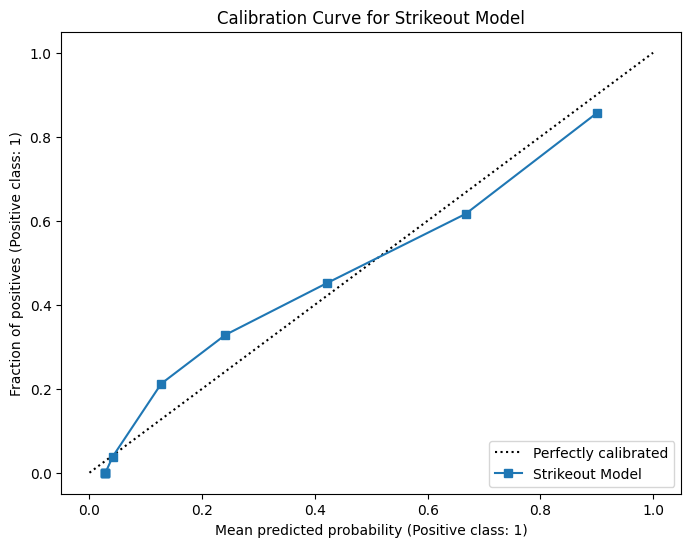

Probability metrics:
Log Loss: 0.31943
Brier Score: 0.10416
Distribution Check:
Real SO Rate: 0.2503
Predicted Avg Prob: 0.2513
Simulated SO Rate: 0.2517


In [ ]:
train_data_s2 = train_data[train_data['target1'] == 1]
val_data_s2 = val_data[val_data['target1'] == 1]
test_data_s2 = test_data[test_data['target1'] == 1]

X2_train = train_data_s2[features]
y2_train = train_data_s2['target2']

X2_val = val_data_s2[features]
y2_val = val_data_s2['target2']

X2_test = test_data_s2[features]
y2_test = test_data_s2['target2']

xgb_so = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_so.fit(X2_train, y2_train, eval_set=[(X2_val, y2_val)], verbose=100)

calibrated_so = CalibratedClassifierCV(FrozenEstimator(xgb_so), method='sigmoid')
calibrated_so.fit(X2_val, y2_val)

y2_proba = calibrated_so.predict_proba(X2_test)[:, 1]

joblib.dump({
    'model': calibrated_so,
    'features': features
}, 'models/so_model_v1.pkl')

importance = pd.Series(
    xgb_so.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y2_test == 1).astype(int),
    y2_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Strikeout Model'
)
plt.title('Calibration Curve for Strikeout Model')
plt.show()

ll = log_loss(y2_test, y2_proba)
brier_score = brier_score_loss(y2_test, y2_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_strikeouts = (np.random.rand(len(y2_proba)) < y2_proba).astype(int)

real_rate = y2_test.mean()
pred_rate = y2_proba.mean()
sim_rate = simulated_strikeouts.mean()

print("Distribution Check:")
print(f"Real SO Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated SO Rate: {sim_rate:.4f}")

### Stage 3: Of Balls in Play, predict Groundball vs Flyball

[0]	validation_0-logloss:0.68059
[100]	validation_0-logloss:0.63976
[200]	validation_0-logloss:0.63309
[300]	validation_0-logloss:0.62995
[400]	validation_0-logloss:0.62840
[500]	validation_0-logloss:0.62750
[600]	validation_0-logloss:0.62679
[700]	validation_0-logloss:0.62639
[800]	validation_0-logloss:0.62595
[900]	validation_0-logloss:0.62561
[1000]	validation_0-logloss:0.62542
[1100]	validation_0-logloss:0.62522
[1200]	validation_0-logloss:0.62501
[1300]	validation_0-logloss:0.62494
[1400]	validation_0-logloss:0.62479
[1466]	validation_0-logloss:0.62480
pitch_type_SI                             0.118628
zone                                      0.079828
plate_z                                   0.045797
batter_zone_average_launch_angle          0.036097
pfx_z                                     0.032126
pitcher_pitch_average_launch_angle        0.029620
batter_pitch_average_launch_angle         0.024250
is_platoon                                0.022751
p_throws_R                  

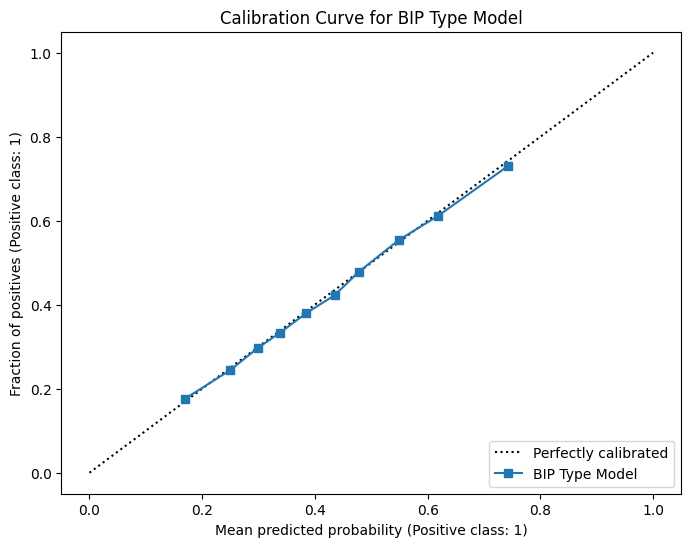

Probability metrics:
Log Loss: 0.62182
Brier Score: 0.21603
Distribution Check:
Real GB Rate: 0.4181
Predicted Avg Prob: 0.4216
Simulated GB Rate: 0.4217


In [25]:
train_data_s3 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0)]
val_data_s3 = val_data[(val_data['target1'] == 1) & (val_data['target2'] == 0)]
test_data_s3 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0)]

X3_train = train_data_s3[features]
y3_train = train_data_s3['target3']

X3_val = val_data_s3[features]
y3_val = val_data_s3['target3']

X3_test = test_data_s3[features]
y3_test = test_data_s3['target3']

xgb_bip = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    min_child_weight=10,
    gamma=0.1,
    early_stopping_rounds=50
)

xgb_bip.fit(X3_train, y3_train, eval_set=[(X3_val, y3_val)], verbose=100)

calibrated_bip = CalibratedClassifierCV(FrozenEstimator(xgb_bip), method='isotonic')
calibrated_bip.fit(X3_val, y3_val)

y3_proba = calibrated_bip.predict_proba(X3_test)[:, 1]

joblib.dump({
    'model': calibrated_bip,
    'features': features
}, 'models/bip_model_v1.pkl')


importance = pd.Series(
    xgb_bip.feature_importances_,
    index=X3_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y3_test == 1).astype(int),
    y3_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='BIP Type Model'
)
plt.title('Calibration Curve for BIP Type Model')
plt.show()

ll = log_loss(y3_test, y3_proba)
brier_score = brier_score_loss(y3_test, y3_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_bip = (np.random.rand(len(y3_proba)) < y3_proba).astype(int)

real_rate = y3_test.mean()
pred_rate = y3_proba.mean()
sim_rate = simulated_bip.mean()

print("Distribution Check:")
print(f"Real GB Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated GB Rate: {sim_rate:.4f}")

### Combine previous models to generate probabilities for out types

In [26]:
def get_pitch_probabilities(X_full, xgb_pa, xgb_so, xgb_bb, X3_columns):
    p_pa_end = xgb_pa.predict_proba(X_full)[:, 1]
    p_no_end = 1.0 - p_pa_end

    p_so_given_end = xgb_so.predict_proba(X_full)[:, 1]

    X_for_stage3 = X_full.reindex(columns=X3_columns, fill_value=0.0)
    stage3_probs = xgb_bb.predict_proba(X_for_stage3)
    p_fb_given_non_so_end = stage3_probs[:, 0]
    p_gb_given_non_so_end = stage3_probs[:, 1]

    p_so = p_pa_end * p_so_given_end
    p_non_so_end = p_pa_end * (1.0 - p_so_given_end)

    p_go = p_non_so_end * p_gb_given_non_so_end
    p_fo = p_non_so_end * p_fb_given_non_so_end

    out = pd.DataFrame({
        'P(None)': p_no_end,
        'P(SO)': p_so,
        'P(GB)': p_go,
        'P(FB)': p_fo
    }, index=X_full.index)

    out['prob_sum'] = out[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)']].sum(axis=1)
    return out

prob_df = get_pitch_probabilities(X1_test, calibrated_out, calibrated_so, calibrated_bip, X3_train.columns)
print(prob_df.head())
print(f"Probability sum min/max: {prob_df['prob_sum'].min():.6f} / {prob_df['prob_sum'].max():.6f}")

test_labels = model_data.loc[X1_test.index]
action_outcomes = ['strikeout', 'groundout', 'flyout', 'hit']

conditions = [
    (test_labels['outcome'] == 'strikeout'),
    
    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),
    
    (test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((test_labels['outcome'].isin(['flyout', 'hit'])) & test_labels['bb_type'].isna()),
    
    (~test_labels['outcome'].isin(action_outcomes))
]

choices = [1, 2, 3, 0]

y_true = np.select(conditions, choices, default=0)

print(pd.Series(y_true).value_counts().sort_index())

final_prob_cols = ['P(None)', 'P(SO)', 'P(GB)', 'P(FB)']
multi_log_loss = log_loss(y_true, prob_df[final_prob_cols], labels=[0, 1, 2, 3])
print(f"Overall Multi-Class Log Loss (None/SO/GB/FB): {multi_log_loss:.4f}")


          P(None)     P(SO)     P(GB)     P(FB)  prob_sum
5805154  0.975591  0.000693  0.015361  0.008355       1.0
5805157  0.962735  0.001058  0.024155  0.012052       1.0
5805163  0.863204  0.003883  0.024305  0.108608       1.0
5805168  0.750815  0.007074  0.085138  0.156973       1.0
5805171  0.959447  0.001151  0.015299  0.024103       1.0
Probability sum min/max: 1.000000 / 1.000000
0    785919
1     59195
2     76006
3    103331
Name: count, dtype: int64
Overall Multi-Class Log Loss (None/SO/GB/FB): 0.5911


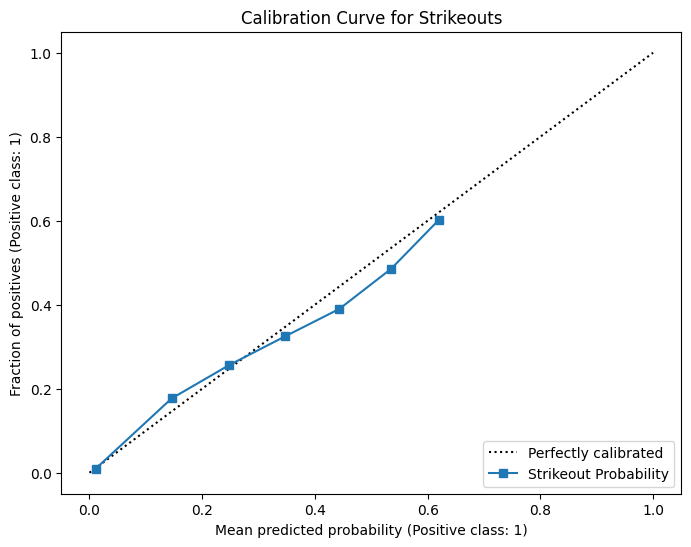

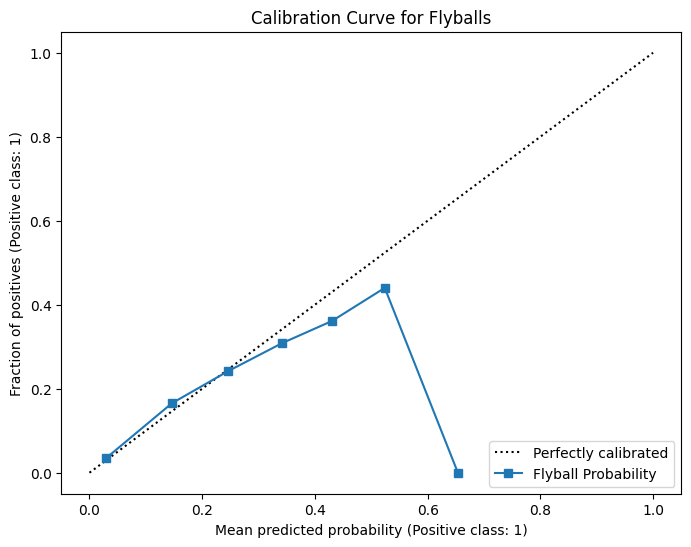

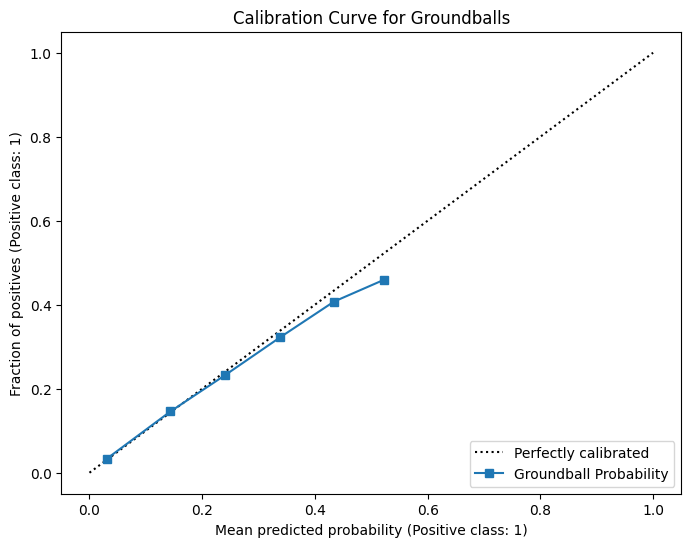

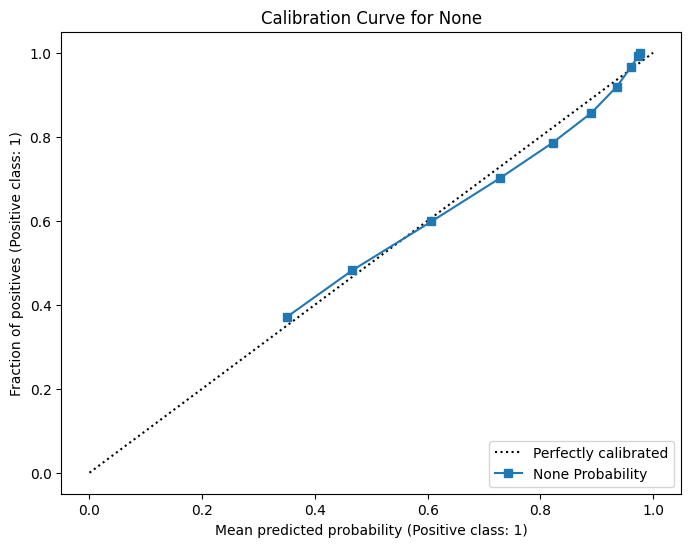

Raw SO Log Loss: 0.2982
Calibrated SO Log Loss: 0.3194
Raw Stage3 Log Loss (BB): 0.6223
Calibrated Stage3 Log Loss (BB): 0.6223
Raw PA End Log Loss: 0.4913
Calibrated PA End Log Loss: 0.4068
Highest P(SO): 69.92%
          P(None)     P(SO)     P(GB)     P(FB)      actual
6587959  0.275989  0.699161  0.012938  0.011911   strikeout
6180011  0.274366  0.683686  0.027181  0.014767   strikeout
6733969  0.296337  0.674038  0.020053  0.009571   strikeout
6200934  0.290911  0.671780  0.028531  0.008779   strikeout
6642494  0.259720  0.668633  0.042868  0.028779        foul
6349141  0.271351  0.667079  0.034541  0.027030   strikeout
6604173  0.288346  0.666787  0.016540  0.028327   strikeout
6211498  0.278008  0.666751  0.023704  0.031537   strikeout
6193109  0.304312  0.666200  0.025329  0.004159   strikeout
6362207  0.274175  0.666087  0.044983  0.014756   strikeout
6801934  0.310388  0.663239  0.015796  0.010577   strikeout
6162084  0.289860  0.658941  0.030665  0.020534   strikeout
6201769

In [27]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 1).astype(int),
    prob_df['P(SO)'],
    n_bins=10,
    ax=ax,
    name='Strikeout Probability'
)
plt.title('Calibration Curve for Strikeouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 3).astype(int),
    prob_df['P(FB)'],
    n_bins=10,
    ax=ax,
    # strategy='quantile',
    name='Flyball Probability'
)
plt.title('Calibration Curve for Flyballs')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 2).astype(int),
    prob_df['P(GB)'],
    n_bins=10,
    ax=ax,
    name='Groundball Probability'
)
plt.title('Calibration Curve for Groundballs')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 0).astype(int),
    prob_df['P(None)'],
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='None Probability'
)
plt.title('Calibration Curve for None')
plt.show()

raw_loss_so = log_loss(y2_test, xgb_so.predict_proba(X2_test)[:, 1])
cal_loss_so = log_loss(y2_test, calibrated_so.predict_proba(X2_test)[:, 1])
print(f'Raw SO Log Loss: {raw_loss_so:.4f}')
print(f'Calibrated SO Log Loss: {cal_loss_so:.4f}')

raw_loss_stage3 = log_loss(y3_test, xgb_bip.predict_proba(X3_test), labels=[0, 1])
cal_loss_stage3 = log_loss(y3_test, xgb_bip.predict_proba(X3_test), labels=[0, 1])
print(f'Raw Stage3 Log Loss (BB): {raw_loss_stage3:.4f}')
print(f'Calibrated Stage3 Log Loss (BB): {cal_loss_stage3:.4f}')

raw_loss_stage1 = log_loss(y1_test, xgb_out.predict_proba(X1_test)[:, 1])
cal_loss_stage1 = log_loss(y1_test, calibrated_out.predict_proba(X1_test)[:, 1])
print(f'Raw PA End Log Loss: {raw_loss_stage1:.4f}')
print(f'Calibrated PA End Log Loss: {cal_loss_stage1:.4f}')

results = X1_test.copy()
results[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)']] = prob_df[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)']]
test_labels = model_data.loc[X1_test.index]

conditions = [
    (test_labels['outcome'] == 'strikeout'),
    
    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),
    
    (test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((test_labels['outcome'].isin(['flyout', 'hit'])) & test_labels['bb_type'].isna())
]

choices = ['strikeout', 'groundball', 'flyball']
results['actual'] = np.select(conditions, choices, default=test_labels['outcome'])

top_so = results.sort_values('P(SO)', ascending=False).head(50)
print(f"Highest P(SO): {top_so['P(SO)'].iloc[0]:.2%}")
print(top_so[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)', 'actual']])

top_fo = results.sort_values('P(FB)', ascending=False).head(50)
print(f"Highest P(FB): {top_fo['P(FB)'].iloc[0]:.2%}")
print(top_fo[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)', 'actual']])

top_go = results.sort_values('P(GB)', ascending=False).head(50)
print(f"Highest P(GB): {top_go['P(GB)'].iloc[0]:.2%}")
print(top_go[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)', 'actual']])

top_none = results.sort_values('P(None)', ascending=False).head(50)
print(f"Highest P(None): {top_none['P(None)'].iloc[0]:.2%}")
print(top_none[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)', 'actual']])

lowest_none = results.sort_values('P(None)', ascending=True).head(50)
print(f"Lowest P(None): {lowest_none['P(None)'].iloc[0]:.2%}")
print(lowest_none[['P(None)', 'P(SO)', 'P(GB)', 'P(FB)', 'actual']])